
# Derivative-Free Conjugate Directions on the Branin–Hoo Function

This notebook demonstrates a **conjugate directions method in the derivative-free setting**, following the spirit of the treatment in **Nocedal and Wright**. The central idea is to reduce a multivariate minimization problem to a sequence of **one-dimensional line searches** along carefully chosen directions, without using derivatives.

For a strictly convex quadratic function, exact line minimization along mutually conjugate directions can recover the minimizer in finitely many steps. On a nonquadratic function such as Branin–Hoo, that exact finite-step property does not hold, but the method still provides a useful structured derivative-free search strategy.

This notebook shows:
1. **step-by-step progress**,
2. the **overall trajectory**,
3. the **objective history**,
4. the **step-size history**.


In [35]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

try:
    rcParams["text.usetex"] = True
except Exception:
    rcParams["text.usetex"] = False

rcParams["font.size"] = 12
rcParams["axes.labelsize"] = 12
rcParams["axes.titlesize"] = 13

np.set_printoptions(precision=6, suppress=True)



## The Branin–Hoo function

We use the standard Branin–Hoo test function
$
f(x_1,x_2)=
a\left(x_2-bx_1^2+cx_1-r\right)^2+s(1-t)\cos(x_1)+s,
$
with
$
a=1,\qquad
b=\frac{5.1}{4\pi^2},\qquad
c=\frac{5}{\pi},\qquad
r=6,\qquad
s=10,\qquad
t=\frac{1}{8\pi}.
$

The usual box domain is
$
x_1\in[-5,10], \qquad x_2\in[0,15].
$


In [36]:

def branin(x):
    x = np.asarray(x, dtype=float)
    x1, x2 = x[..., 0], x[..., 1]
    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s

bounds = np.array([[-5.0, 10.0],
                   [ 0.0, 15.0]])

def project_to_bounds(x, bounds=bounds):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], bounds[0, 0], bounds[0, 1])
    x[1] = np.clip(x[1], bounds[1, 0], bounds[1, 1])
    return x


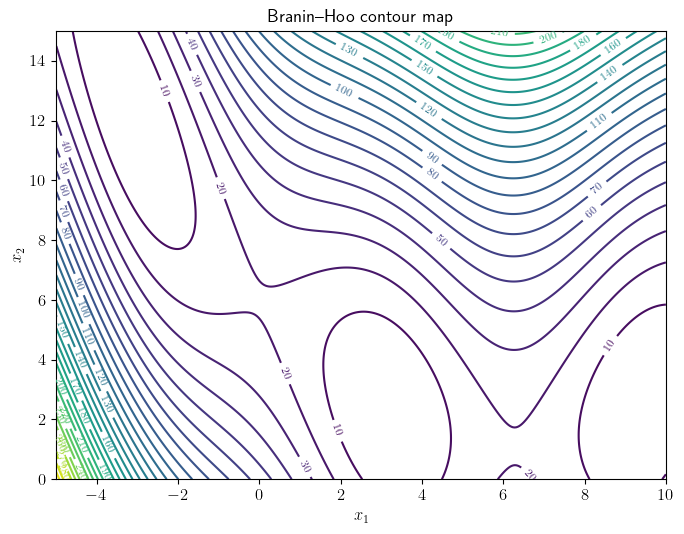

In [37]:

x1 = np.linspace(bounds[0,0], bounds[0,1], 400)
x2 = np.linspace(bounds[1,0], bounds[1,1], 400)
X1, X2 = np.meshgrid(x1, x2)
F = branin(np.stack([X1, X2], axis=-1))

plt.figure(figsize=(7, 5.5))
cs = plt.contour(X1, X2, F, levels=30)
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Branin--Hoo contour map")
plt.tight_layout()
plt.show()



## Method outline

In a derivative-free conjugate-directions framework, we maintain a set of directions
$
\{d_1,\dots,d_n\},
$
and perform line minimizations along them. In two dimensions, one cycle consists of two successive line searches.

A classical derivative-free strategy, in the spirit of Nocedal and Wright, is:

- begin with coordinate directions,
  $
  d_1=e_1,\qquad d_2=e_2,
  $
- carry out line minimizations along these directions,
- after the cycle, compute the total displacement
  $
  d_{\mathrm{new}} = x_{\mathrm{end}}-x_{\mathrm{start}},
  $
- discard one old direction and append this new direction.

For a general nonlinear function, these directions are not exactly conjugate in the strict quadratic sense, but the mechanism captures the essential derivative-free conjugate-directions idea: build better directions from the progress made during previous searches.



## A derivative-free line search

To stay derivative-free, we minimize the one-dimensional function
$
\phi(\alpha)=f( \mathbf{x} + \alpha \mathbf{p})
$
numerically over a bounded interval. In this notebook, this is done by sampling a dense grid of $\alpha$ values and choosing the best one.

This is not the most sophisticated line search, but it is transparent and easy to demonstrate.


In [39]:

def line_search_grid(f, x, d, alpha_max=4.0, ngrid=401, bounds=bounds):
    """
    Derivative-free 1D search over alpha in [-alpha_max, alpha_max].
    The direction is normalized first, so alpha has units of distance.
    """
    d = np.asarray(d, dtype=float)
    norm_d = np.linalg.norm(d)
    if norm_d == 0.0:
        fx = float(f(x))
        return {
            "alpha_star": 0.0,
            "x_new": x.copy(),
            "f_new": fx,
            "alphas": np.array([0.0]),
            "phi_vals": np.array([fx]),
            "direction_unit": np.zeros_like(d),
        }

    d_unit = d / norm_d
    alphas = np.linspace(-alpha_max, alpha_max, ngrid)

    phi_vals = []
    xs = []
    for alpha in alphas:
        x_trial = project_to_bounds(x + alpha * d_unit, bounds)
        xs.append(x_trial)
        phi_vals.append(float(f(x_trial)))

    phi_vals = np.array(phi_vals, dtype=float)
    xs = np.array(xs, dtype=float)
    idx = int(np.argmin(phi_vals))

    return {
        "alpha_star": float(alphas[idx]),
        "x_new": xs[idx].copy(),
        "f_new": float(phi_vals[idx]),
        "alphas": alphas,
        "phi_vals": phi_vals,
        "direction_unit": d_unit.copy(),
    }



## Derivative-free conjugate directions algorithm

In two dimensions, one cycle consists of:
1. a line search along the first direction,
2. a line search along the second direction,
3. formation of a new direction from the net displacement over the cycle,
4. replacement of one old direction by this new direction.

This produces a structured derivative-free method that is richer than repeatedly searching only along the coordinate axes.


In [40]:

def derivative_free_conjugate_directions(
    f,
    x0,
    directions0=None,
    alpha_max=4.0,
    ngrid=401,
    max_cycles=20,
    tol_disp=1e-4,
    tol_f=1e-8,
    bounds=bounds,
):
    x = project_to_bounds(x0, bounds)
    fx = float(f(x))

    n = len(x)
    if directions0 is None:
        directions = [np.eye(n)[i].copy() for i in range(n)]
    else:
        directions = [np.asarray(d, dtype=float).copy() for d in directions0]

    history = [{
        "stage": "start",
        "cycle": 0,
        "substep": 0,
        "x": x.copy(),
        "f": fx,
        "direction": None,
        "alpha": 0.0,
        "step_norm": 0.0,
        "directions_snapshot": [d.copy() for d in directions],
        "line_search": None,
    }]

    for cycle in range(1, max_cycles + 1):
        x_cycle_start = x.copy()
        f_cycle_start = fx
        old_directions = [d.copy() for d in directions]

        for j, d in enumerate(old_directions, start=1):
            ls = line_search_grid(
                f=f,
                x=x,
                d=d,
                alpha_max=alpha_max,
                ngrid=ngrid,
                bounds=bounds,
            )

            x_new = ls["x_new"]
            f_new = ls["f_new"]
            alpha_star = ls["alpha_star"]
            step_norm = float(np.linalg.norm(x_new - x))

            x = x_new
            fx = f_new

            history.append({
                "stage": "line_search",
                "cycle": cycle,
                "substep": j,
                "x": x.copy(),
                "f": fx,
                "direction": d.copy(),
                "alpha": alpha_star,
                "step_norm": step_norm,
                "directions_snapshot": [dd.copy() for dd in directions],
                "line_search": ls,
            })

        displacement = x - x_cycle_start
        disp_norm = float(np.linalg.norm(displacement))

        history.append({
            "stage": "cycle_summary",
            "cycle": cycle,
            "substep": 0,
            "x": x.copy(),
            "f": fx,
            "direction": displacement.copy(),
            "alpha": None,
            "step_norm": disp_norm,
            "directions_snapshot": [d.copy() for d in directions],
            "line_search": None,
        })

        if disp_norm < tol_disp or abs(f_cycle_start - fx) < tol_f:
            break

        if disp_norm > 0.0:
            directions = directions[1:] + [displacement.copy()]
        else:
            break

    return history



## Run the method from a chosen initial point


In [41]:

x0 = np.array([6.0, 12.0])

hist = derivative_free_conjugate_directions(
    branin,
    x0=x0,
    alpha_max=4.0,
    ngrid=401,
    max_cycles=20,
    tol_disp=1e-4,
    tol_f=1e-8,
    bounds=bounds,
)

print("Initial point x0 =", x0)
print("Initial f(x0) =", branin(x0))
print("Final point =", hist[-1]["x"])
print("Final value =", hist[-1]["f"])
print("Number of stored records =", len(hist))
print("Completed cycles =", max(r["cycle"] for r in hist))


Initial point x0 = [ 6. 12.]
Initial f(x0) = 138.00032784720685
Final point = [2.720823 2.349591]
Final value = 1.3118441546518778
Number of stored records = 13
Completed cycles = 4


In [30]:
hist

[{'stage': 'start',
  'cycle': 0,
  'substep': 0,
  'x': array([ 6., 12.]),
  'f': 138.00032784720685,
  'direction': None,
  'alpha': 0.0,
  'step_norm': 0.0,
  'directions_snapshot': [array([1., 0.]), array([0., 1.])],
  'line_search': None},
 {'stage': 'line_search',
  'cycle': 1,
  'substep': 1,
  'x': array([ 2., 12.]),
  'f': 81.1099211533855,
  'direction': array([1., 0.]),
  'alpha': -4.0,
  'step_norm': 4.0,
  'directions_snapshot': [array([1., 0.]), array([0., 1.])],
  'line_search': {'alpha_star': -4.0,
   'x_new': array([ 2., 12.]),
   'f_new': 81.1099211533855,
   'alphas': array([-4.  , -3.98, -3.96, -3.94, -3.92, -3.9 , -3.88, -3.86, -3.84,
          -3.82, -3.8 , -3.78, -3.76, -3.74, -3.72, -3.7 , -3.68, -3.66,
          -3.64, -3.62, -3.6 , -3.58, -3.56, -3.54, -3.52, -3.5 , -3.48,
          -3.46, -3.44, -3.42, -3.4 , -3.38, -3.36, -3.34, -3.32, -3.3 ,
          -3.28, -3.26, -3.24, -3.22, -3.2 , -3.18, -3.16, -3.14, -3.12,
          -3.1 , -3.08, -3.06, -3.04, -3.02,


## Step-by-step progress

The printout below shows, cycle by cycle:
- the direction used,
- the line-search step length $\alpha^\star$,
- the accepted new point,
- the objective value,
- and the move size.

This is the most useful section for walking through the algorithm live.


In [42]:

def print_progress(history, max_cycles_to_print=5):
    for rec in history:
        if rec["cycle"] > max_cycles_to_print:
            continue

        if rec["stage"] == "start":
            print("Start")
            print(f"  x = {rec['x']}")
            print(f"  f = {rec['f']:.6f}")
            print("  initial directions:")
            for d in rec["directions_snapshot"]:
                print(f"    {d}")
            print()

        elif rec["stage"] == "line_search":
            print(f"Cycle {rec['cycle']}, line search {rec['substep']}")
            print(f"  direction = {rec['direction']}")
            print(f"  alpha_*   = {rec['alpha']:.6f}")
            print(f"  x_new     = {rec['x']}")
            print(f"  f_new     = {rec['f']:.6f}")
            print(f"  step_norm = {rec['step_norm']:.6f}")
            print()

        elif rec["stage"] == "cycle_summary":
            print(f"Cycle {rec['cycle']} summary")
            print(f"  x_end        = {rec['x']}")
            print(f"  f_end        = {rec['f']:.6f}")
            print(f"  displacement = {rec['direction']}")
            print(f"  disp_norm    = {rec['step_norm']:.6f}")
            print()

print_progress(hist, max_cycles_to_print=5)

Start
  x = [ 6. 12.]
  f = 138.000328
  initial directions:
    [1. 0.]
    [0. 1.]

Cycle 1, line search 1
  direction = [1. 0.]
  alpha_*   = -4.000000
  x_new     = [ 2. 12.]
  f_new     = 81.109921
  step_norm = 4.000000

Cycle 1, line search 2
  direction = [0. 1.]
  alpha_*   = -4.000000
  x_new     = [2. 8.]
  f_new     = 27.779035
  step_norm = 4.000000

Cycle 1 summary
  x_end        = [2. 8.]
  f_end        = 27.779035
  displacement = [-4. -4.]
  disp_norm    = 5.656854

Cycle 2, line search 1
  direction = [0. 1.]
  alpha_*   = -4.000000
  x_new     = [2. 4.]
  f_new     = 6.448148
  step_norm = 4.000000

Cycle 2, line search 2
  direction = [-4. -4.]
  alpha_*   = -0.640000
  x_new     = [2.452548 4.452548]
  f_new     = 5.081358
  step_norm = 0.640000

Cycle 2 summary
  x_end        = [2.452548 4.452548]
  f_end        = 5.081358
  displacement = [ 0.452548 -3.547452]
  disp_norm    = 3.576201

Cycle 3, line search 1
  direction = [-4. -4.]
  alpha_*   = 0.000000
  x_new


## Visualize the one-dimensional searches

For a few early searches, we plot
$
\phi(\alpha)=f(\mathbf{x} + \alpha \mathbf{p}),
$
so that the line-search mechanism becomes explicit.


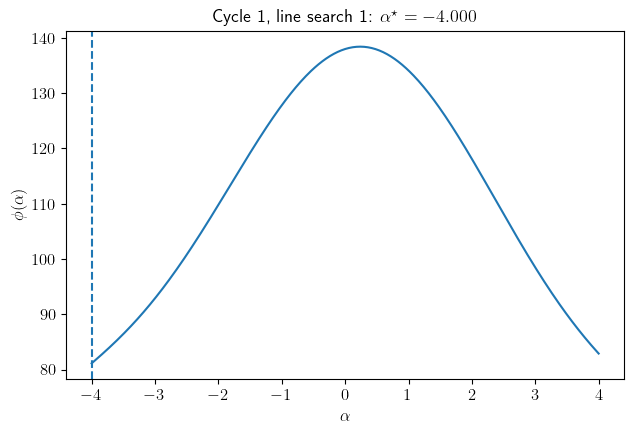

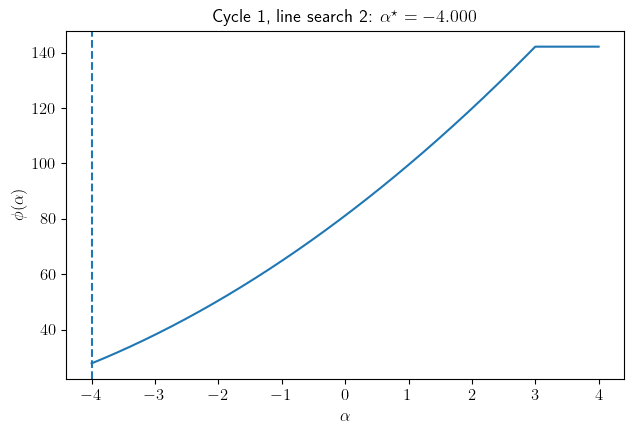

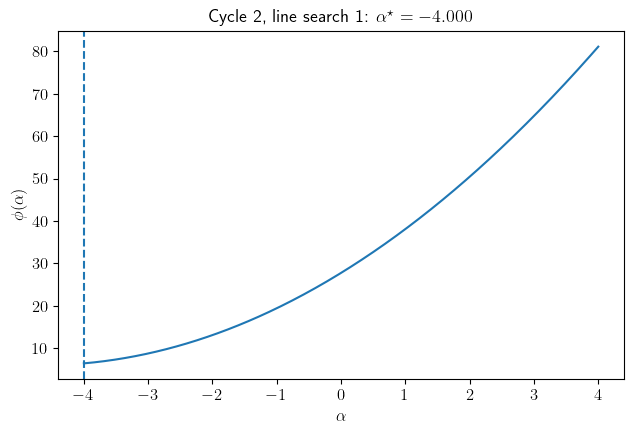

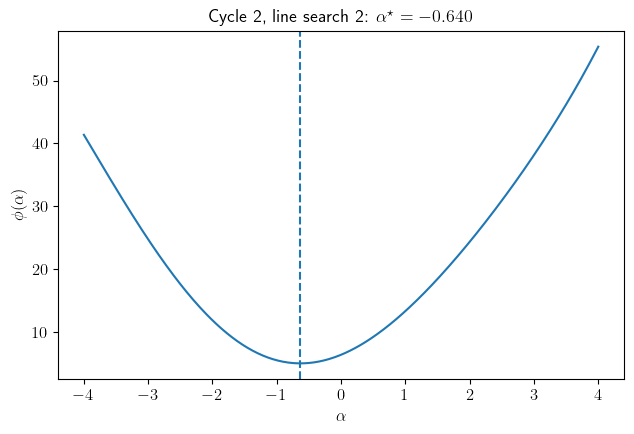

In [43]:

line_search_records = [r for r in hist if r["stage"] == "line_search"]

num_to_plot = min(4, len(line_search_records))
for i in range(num_to_plot):
    rec = line_search_records[i]
    ls = rec["line_search"]

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(ls["alphas"], ls["phi_vals"])
    plt.axvline(rec["alpha"], linestyle="--")
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$\phi(\alpha)$")
    plt.title(
        rf"Cycle {rec['cycle']}, line search {rec['substep']}: "
        rf"$\alpha^\star={rec['alpha']:.3f}$"
    )
    plt.tight_layout()
    plt.show()



## Overall trajectory


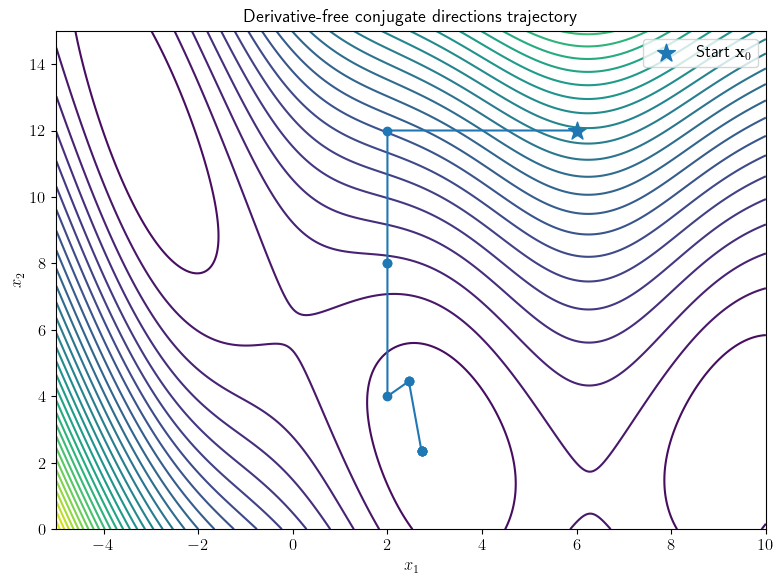

In [45]:

traj = np.array(
    [rec["x"] for rec in hist if rec["stage"] in ["start", "line_search", "cycle_summary"]],
    dtype=float
)

plt.figure(figsize=(8, 6))
plt.contour(X1, X2, F, levels=35)
plt.plot(traj[:, 0], traj[:, 1], marker="o")
plt.scatter([x0[0]], [x0[1]], marker="*", s=180, label=r"Start $\mathbf{x}_0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Derivative-free conjugate directions trajectory")
plt.legend()
plt.tight_layout()
plt.savefig("figures/branin_cd_trajectory.png")



## Objective history


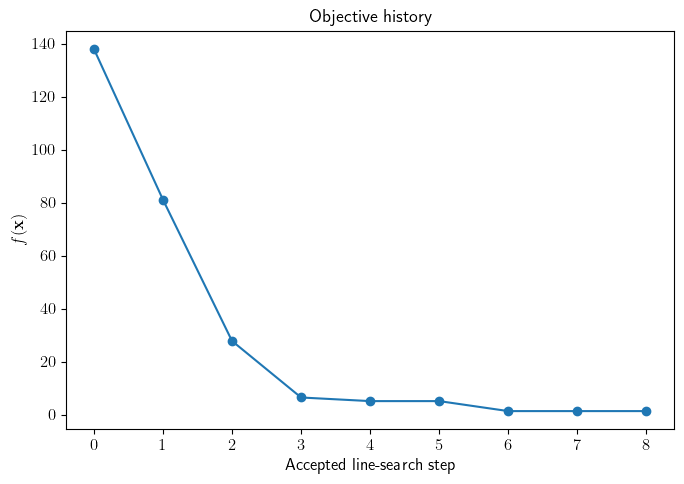

In [33]:

line_recs = [r for r in hist if r["stage"] == "line_search"]
f_hist = np.array([hist[0]["f"]] + [r["f"] for r in line_recs], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(f_hist)), f_hist, marker="o")
plt.xlabel("Accepted line-search step")
plt.ylabel(r"$f(\mathbf{x})$")
plt.title(r"Objective history")
plt.tight_layout()
plt.savefig("figures/branin_cd_objhistory.png")



## Step-size history

Since the method is built around line searches rather than a single global step parameter, a natural definition of step size here is
\[
\|x_{k+1}-x_k\|.
\]


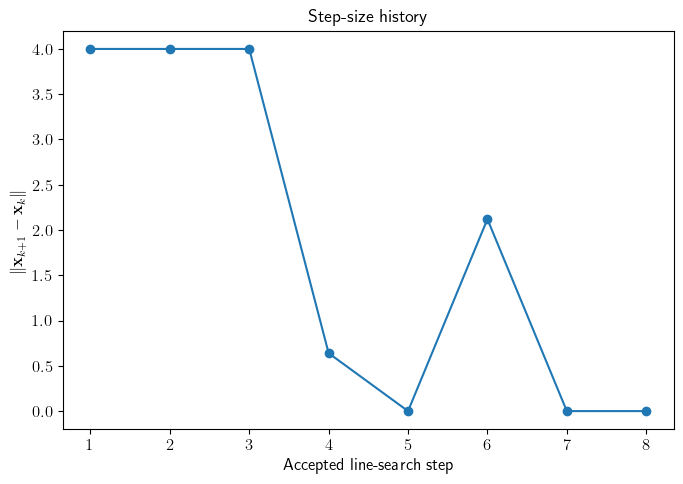

In [31]:

step_hist = np.array([r["step_norm"] for r in line_recs], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(step_hist)+1), step_hist, marker="o")
plt.xlabel("Accepted line-search step")
plt.ylabel(r"$\|\mathbf{x}_{k+1} - \mathbf{x}_k\|$")
plt.title(r"Step-size history")
plt.tight_layout()
plt.show()



## Cycle-level summary


In [25]:

cycle_summaries = [r for r in hist if r["stage"] == "cycle_summary"]

for rec in cycle_summaries:
    print(
        f"Cycle {rec['cycle']:2d}: "
        f"f = {rec['f']:.6f}, "
        f"x = {rec['x']}, "
        f"displacement norm = {rec['step_norm']:.6f}"
    )


Cycle  1: f = 27.779035, x = [2. 8.], displacement norm = 5.656854
Cycle  2: f = 5.081358, x = [2.452548 4.452548], displacement norm = 3.576201
Cycle  3: f = 1.311844, x = [2.720823 2.349591], displacement norm = 2.120000
Cycle  4: f = 1.311844, x = [2.720823 2.349591], displacement norm = 0.000000



## Discussion

This example shows the main derivative-free conjugate-directions idea clearly:

- perform structured line searches rather than local polling,
- use the accumulated displacement over a cycle to generate a better direction,
- and repeat.

For a truly quadratic objective with exact line searches, conjugate directions have a finite-step interpretation. On the nonconvex Branin–Hoo function, the method is better viewed as a pedagogical analogue of that classical theory. It still illustrates why direction updating can produce more coordinated movement than repeatedly searching only along the coordinate axes.
